# CellTypist - Bacteria dataset 
This CellTypist tutorial is applied on a Bacterie scRNA-seq dataset with 17.712 cells en 2.799 genes.
The dataset consists of 2 celltypes: BF (bacteriofague-infected cels) and P (prokaryotes/controls).

## 1. Install CellTypist Package

In [9]:
!pip install celltypist


## 2. Import the libraries

In [10]:
import scanpy as sc #toolkit for single-cell analysis
import celltypist #automatic cell-annotation
from celltypist import models # to download specific models
import numpy as np #calculataions
import matplotlib.pyplot as plt #making some graphs

sc.settings.verbosity = 1  # Only show errors and warnings
sc.settings.set_figure_params(dpi=100, frameon=False) # Set figure quality to 100 dpi, no border

## 3. Load the bacteria data
The bacteria dataset contains of the Staphylococcus aureus bacteria in two different growth states. The whole point of the study was to compare how these two populations differ in gene expression at the single-cell level. Biofilm cells are much harder to treat and more resistant to the immune system, which is why understanding their transcriptional differences from planktonic cells is so important.

In [11]:
adata_bacteria = sc.read('Bacteria_dataset.h5ad')

In [12]:
#look at the shape of the dataset,
adata_bacteria.shape

(17712, 2799)

In [13]:
# Show 5 BF and 5 P cells for comparison
import pandas as pd
bf_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'BF'].head(5)
p_cells = adata_bacteria.obs[adata_bacteria.obs['Type_of_cells'] == 'P'].head(5)
print(pd.concat([bf_cells, p_cells]))

     non_ribo_counts Type_of_cells sample
68         14.120000            BF     bf
96          8.600000            BF     bf
104        16.809999            BF     bf
107         8.700001            BF     bf
131         9.559999            BF     bf
1          38.130001             P      p
14          7.260000             P      p
25          9.630001             P      p
45          7.400000             P      p
51          9.530001             P      p


The dataset shows the 2 types of Staphylococcus aureus: 
Planktonic (P)
Biofilm (BF)

## 4. Preprocessing
The data is already log1p-normalised, we can check this by checking the counts per cell. If the result is 10k, we know the the log1p is already done.

In [14]:
counts_per_cell = np.expm1(adata_bacteria.X).sum(axis=1)  # Turn the log1p back to raw data
print('Counts per cell (min/max/average):')
print(f'  min:  {counts_per_cell.min():.1f}')
print(f'  max:  {counts_per_cell.max():.1f}')
print(f'  mean: {counts_per_cell.mean():.1f}')


Counts per cell (min/max/average):
  min:  10000.0
  max:  10000.0
  mean: 10000.0


#### Neighborhood graph
By building a neighborhood graph, we connect cells that are similar to each other based on their gene expression. 
Due to the high number of cells and genes, it's hard to visualize or cluster them directly. 
The first step is performing a PCA, which reduces the data to 40 principal components.
The second step is building the neighborhood graph, where the model finds the 15 most similar cells in PCA space.
Using 15 neighbors balances stability — too few leads to noisy clusters, too many causes them to merge. Finally, UMAP reduces this graph to 2 dimensions for visualization.


In [15]:
# PCA, Build a neighborhood graph and calculate UMAP (for visualisation)
sc.tl.pca(adata_bacteria, n_comps=40)        # Reducing the data to 40 dimensions
sc.pp.neighbors(adata_bacteria, n_neighbors=15, n_pcs=40)  # Searched for the 15 neighbors 
sc.tl.umap(adata_bacteria)                   # 2D graph for visualisation

/home/nvanacker/miniconda3/envs/inab/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 5. Train a custom celltypist model on the bacteria dataset
The integrated CellTypist models are based on human immune cells.
we'll train an new (own) model on the bacteria dataset by using a trainingset and a test set 


In [33]:
# Splits in train (80%) en test (20%)
np.random.seed(42) #Fixed starting point, we use the same random split every time
n_cells = adata_bacteria.n_obs #n_obs= number of observations = total number of cells
idx = np.random.permutation(n_cells) #creates a randomly shuffled list of cell indices. We got a randomized train/test split, which is not biased
train_idx = idx[:int(0.8 * n_cells)] # Everything UP TO position 80% = training data
test_idx = idx[int(0.8 * n_cells):] # Everything FROM position 80% = test data

adata_train = adata_bacteria[train_idx].copy()
adata_test = adata_bacteria[test_idx].copy()

print(f'Trainingsset: {adata_train.shape[0]} cells')
print(f'Test set:    {adata_test.shape[0]} cells')
print()
print('Trainingsset celtype distribution:')
print(adata_train.obs['Type_of_cells'].value_counts().to_string())
print()
print('Test set celtype distribution:')
print(adata_test.obs['Type_of_cells'].value_counts().to_string())

Trainingsset: 14169 cells
Test set:    3543 cells

Trainingsset celtype distribution:
P     11354
BF     2815

Test set celtype distribution:
P     2870
BF     673


In [25]:
# Train het custom CellTypist model
# labels = 'Type_of_cells' is the column with celltype labels in adata_train.obs

new_model = celltypist.train(
    adata_train,
    labels='Type_of_cells',
    n_jobs=4,
    feature_selection=True,
    top_genes=500
)
print('Model getraind!')
print(new_model)

🍳 Preparing data before training
🔬 Input data has 14169 cells and 2799 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 500 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


Model getraind!
CellTypist model with 2 cell types and 500 features
    date: 2026-04-30 10:26:15.778095
    cell types: BF, P
    features: thiolase-like protein, MBL fold metallo-hydrolase, ..., SAUSA300_RS14670


In [26]:
# save the model 
new_model.write('bacteria_celltypist_model.pkl')


A custom CellTypist model is trained on the training set using logistic regression. The labels parameter tells the model which column contains the cell type labels (BF or P). Feature selection is enabled to automatically select the 500 most informative genes out of 2,799 for classification. 
The model is then saved as a .pkl file for reuse.

## 6. Annotate the test dataset with the custom model
The trained model (bacteria_celltypist_model.pkl) is now applied to the test set (3,543 cells) to predict whether each cell is Planktonic (P) or Biofilm (BF).
CellTypist uses the 500 most informative genes to scale and classify each cell. Majority voting is enabled, which means that cells in the same neighborhood cluster vote together to improve prediction accuracy and reduce noise. 
The result is a table with three columns:
1. predicted_labels (the raw prediction per cell)
2. over_clustering (the cluster the cell belongs to)
3. majority_voting (the final refined prediction after voting).

In [27]:
# Annotate the test dataset
predictions = celltypist.annotate(
    adata_test,
    model='bacteria_celltypist_model.pkl',
    majority_voting=True
)

🔬 Input data has 3543 cells and 2799 genes
🔗 Matching reference genes in the model
🧬 500 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


In [32]:
# watch the predicted labels
predictions.predicted_labels.head(10)

,predicted_labels,over_clustering,majority_voting
68262,P,24,P
280980,P,4,P
205690,P,51,P
205916,P,38,P
99370,BF,82,P
282450,P,64,P
241596,P,110,P
216979,P,125,P
272348,P,105,P
177577,P,25,P


## 7. Comparison of true labels vs. predicted labels 
The predictions are converted into an AnnData object using predictions.to_adata(), the standard data format in Scanpy. It is an organized container that stores both the cell data (genes, counts) and the metadata per cell (such as Type_of_cells, predicted_labels, majority_voting, and conf_score). This allows the predictions to be easily combined with the original cell data for further analysis and visualization.


In [36]:
# Zet de resultaten om in een AnnData object
adata_test_annotated = predictions.to_adata()
#print('Obs kolommen na annotatie:', list(adata_test_annotated.obs.columns))
adata_test_annotated.obs[['Type_of_cells', 'predicted_labels', 'majority_voting', 'conf_score']].head(10)

,Type_of_cells,predicted_labels,majority_voting,conf_score
68262,P,P,P,0.776422
280980,P,P,P,0.624868
205690,P,P,P,0.809838
205916,P,P,P,0.973910
99370,BF,BF,P,0.637340
282450,P,P,P,0.907704
241596,P,P,P,0.823045
216979,P,P,P,0.829382
272348,P,P,P,0.729100
177577,P,P,P,0.966909


The table compares the true cell type labels with the model's predictions. predicted_labels shows the raw prediction per cell, majority_voting shows the refined prediction after neighboring cells voted together, and conf_score indicates how confident the model was, where a score closer to 1 means higher confidence. In this sample of 10 cells, 9 out of 10 are correctly predicted. Cell 99370 is notable — it is truly a BF cell, correctly identified by predicted_labels, but incorrectly overruled to P by majority voting, likely because its neighbors were predominantly Planktonic.

## 8. Visualisations of the predictions
First, the UMAP is recalculated specifically for the test set, since a separate neighborhood graph is needed for visualization. Three UMAP plots are then generated side by side to compare the true cell types, the raw predicted labels, and the majority voting predictions. Each dot represents a single cell, colored by its label.

In [38]:
# Recalculate PCA, neighbors and UMAP for the test set
sc.tl.pca(adata_test_annotated, n_comps=40)          # Reduce to 40 principal components
sc.pp.neighbors(adata_test_annotated, n_neighbors=15, n_pcs=40)  # Find 15 most similar cells per cell
sc.tl.umap(adata_test_annotated)                      # Project everything to 2D for visualization

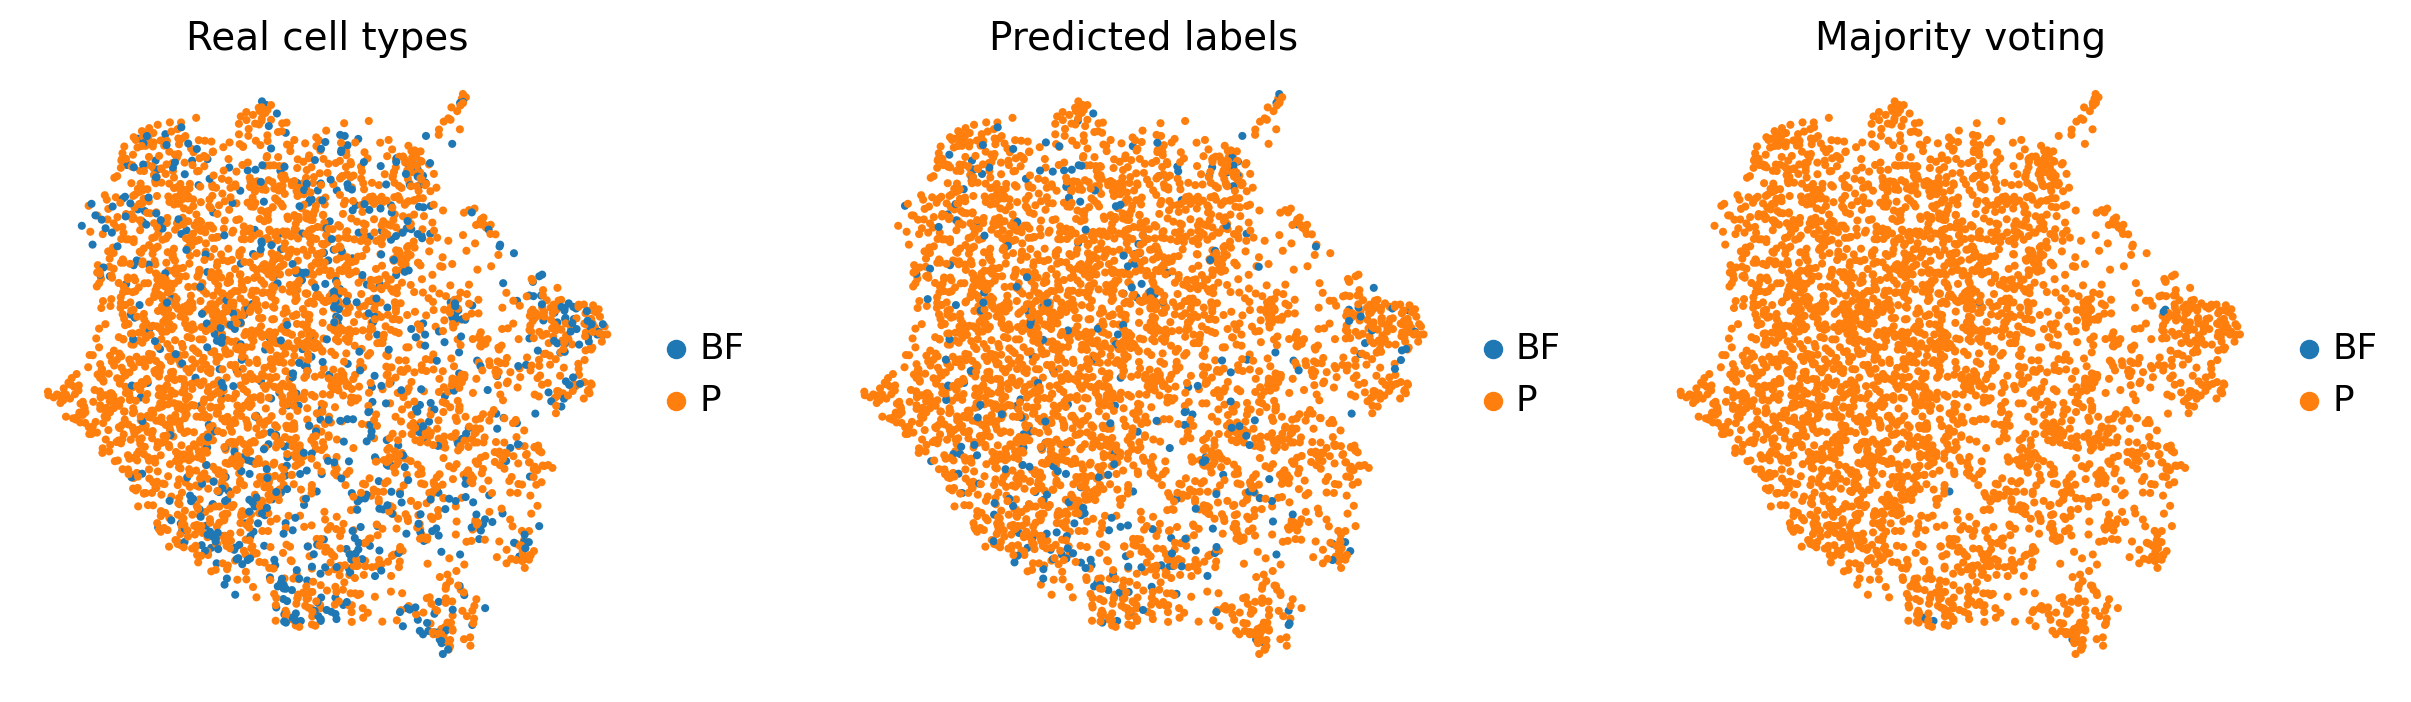

In [45]:
# Plot real cell types, predicted labels and majority voting side by side for comparison
sc.pl.umap(
    adata_test_annotated,
    color=['Type_of_cells', 'predicted_labels', 'majority_voting'],
    legend_loc='right margin',
    title=['Real cell types', 'Predicted labels', 'Majority voting']
)

The three UMAP plots reveal an important limitation of the model. The real cell types show a clear mix of Planktonic (P, orange) and Biofilm (BF, blue) cells. The predicted labels correctly identify most P cells but miss a large portion of BF cells. After majority voting, almost all BF predictions disappear entirely, as BF cells are outvoted by the surrounding P majority.
This is likely explained by a class imbalance that was already present in the original dataset — with 14,224 P cells versus only 3,488 BF cells (~80% vs ~20%), the model develops a strong bias towards predicting P. This imbalance was not caused by the train/test split, but reflects the true composition of the dataset.

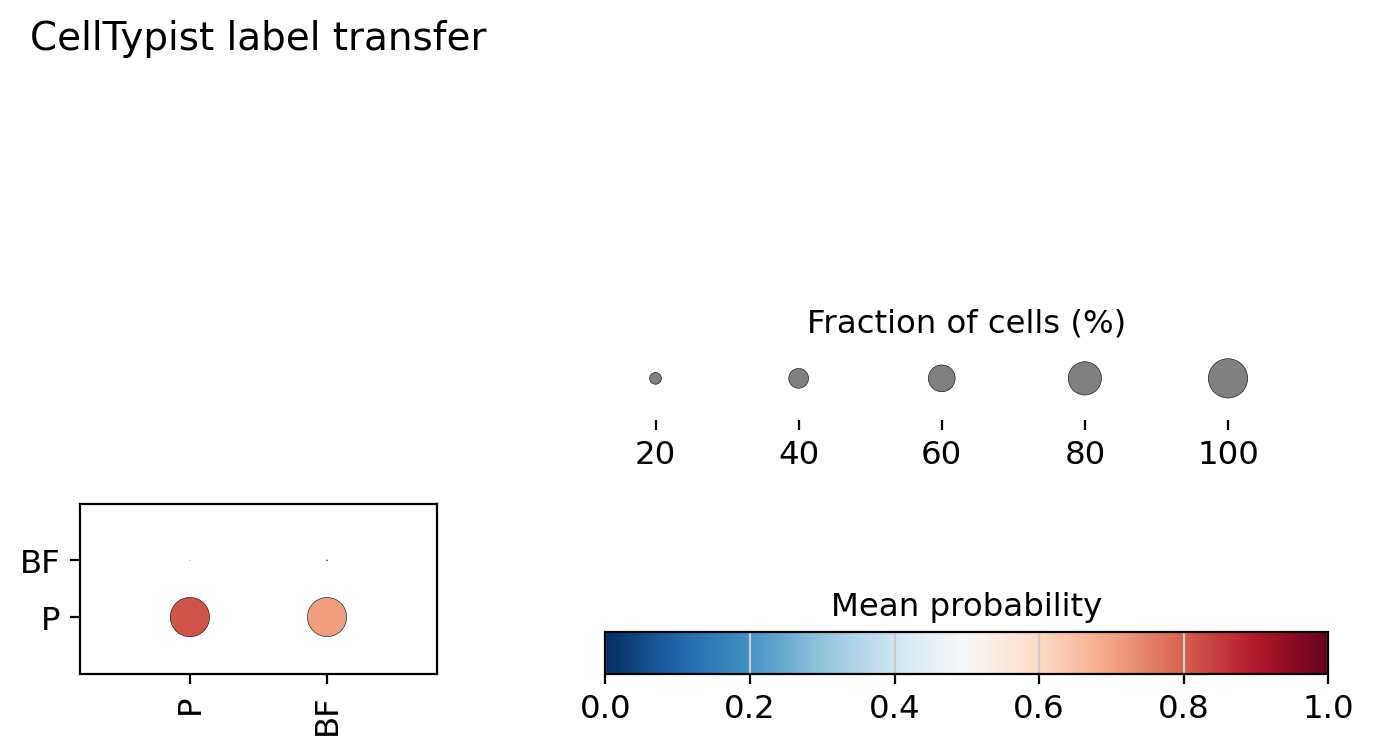

In [53]:
# Dotplot: Compare the real celtypes with CellTypist predictions
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
celltypist.dotplot(
    predictions,
    use_as_reference='Type_of_cells',
    use_as_prediction='majority_voting',
    ax=ax
)
plt.show()

## 8. Evaluatie: Accuracy of the predictions

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

y_true = adata_test_annotated.obs['Type_of_cells']
y_pred = adata_test_annotated.obs['majority_voting']

print('=== Classification report ===')
print(classification_report(y_true, y_pred))

print('=== Confusion matrix ===')
print(confusion_matrix(y_true, y_pred))

=== Classification report ===
              precision    recall  f1-score   support

          BF       0.86      0.01      0.02       673
           P       0.81      1.00      0.90      2870

    accuracy                           0.81      3543
   macro avg       0.83      0.50      0.46      3543
weighted avg       0.82      0.81      0.73      3543

=== Confusion matrix ===
[[   6  667]
 [   1 2869]]


## 9. Look at the top marker genes per celltympe 

In [25]:
# Load the saved model
model = models.Model.load('bacteria_celltypist_model.pkl')

# Show celltypes in the model 
print('Celtypen in model:', model.cell_types)

Celtypen in model: ['BF' 'P']


In [26]:
# Extract de top 5 marker genes per celltype
for ct in model.cell_types:
    top_genes = model.extract_top_markers(ct, 5)
    print(f'Top 5 marker genen voor [{ct}]:', top_genes)

Top 5 marker genen voor [BF]: ['SAUSA300_RS15875' 'IS200/IS605 family transposase' 'SAUSA300_RS02555'
 'dapA' 'trnaD-2']
Top 5 marker genen voor [P]: ['SAUSA300_RS15870' 'SAUSA300_RS07720' 'SAUSA300_RS08235'
 'SAUSA300_RS05725' 'SAUSA300_RS13590']


Top 3 genen voor BF: ['SAUSA300_RS15875' 'IS200/IS605 family transposase' 'SAUSA300_RS02555']


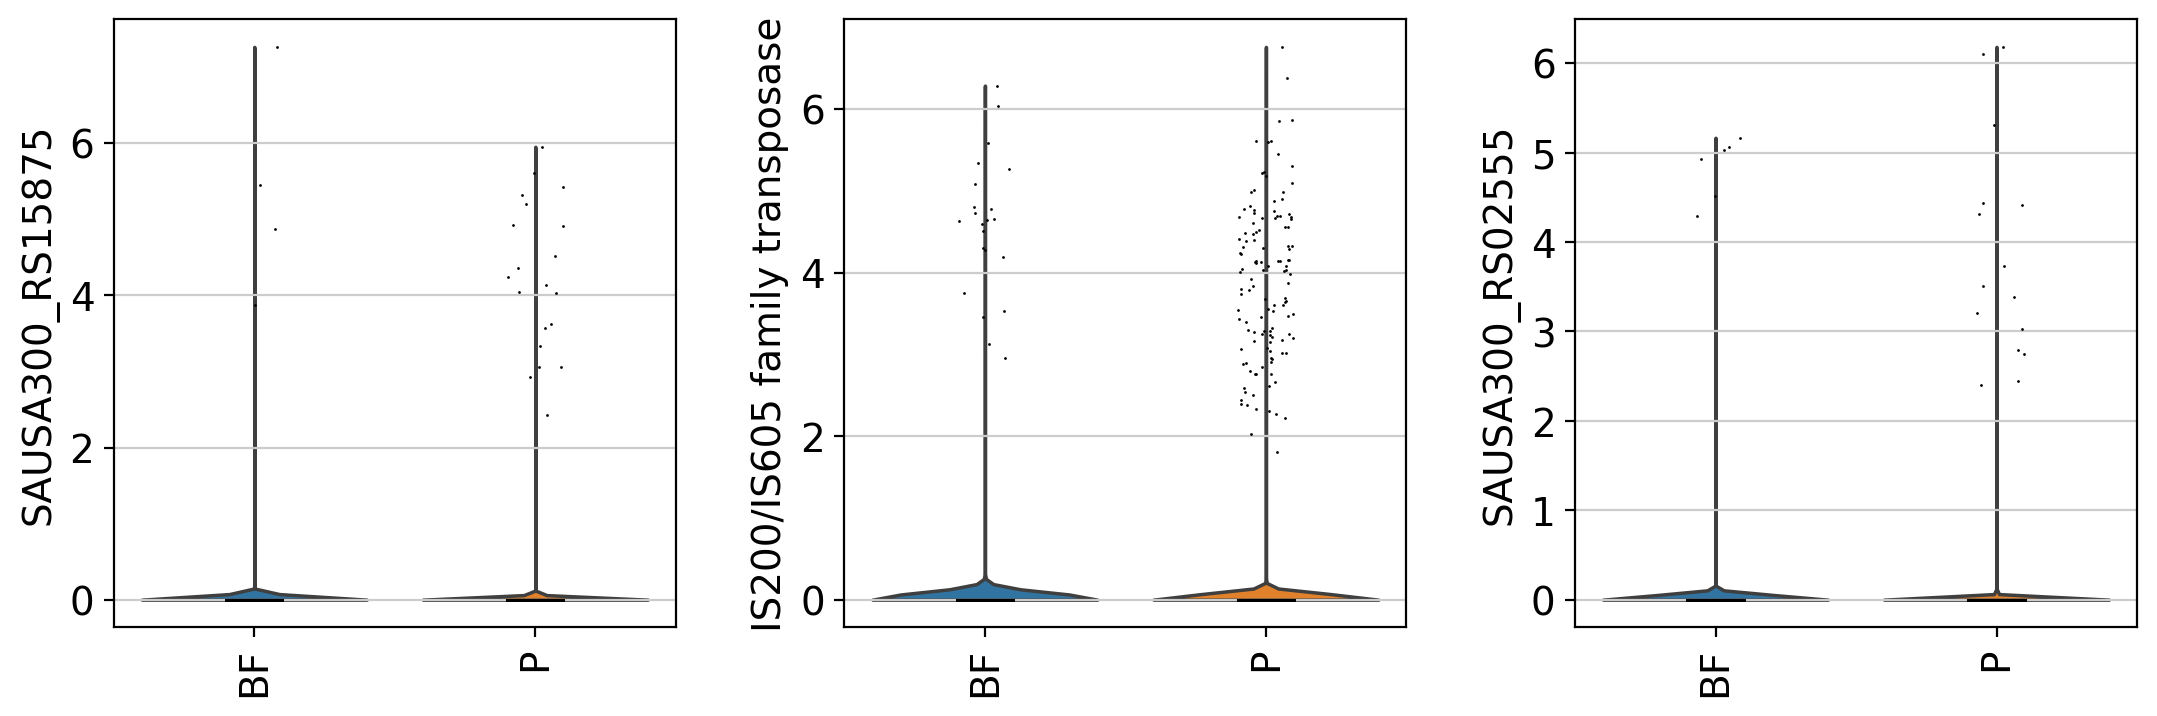

In [33]:
# Visualiseer expressie van top 3 marker genen voor BF cellen in de trainingsset
top_bf_genes = model.extract_top_markers('BF', 3)
print('Top 3 genen voor BF:', top_bf_genes)

sc.pl.violin(
    adata_train,
    top_bf_genes,
    groupby='Type_of_cells',
    rotation=90)

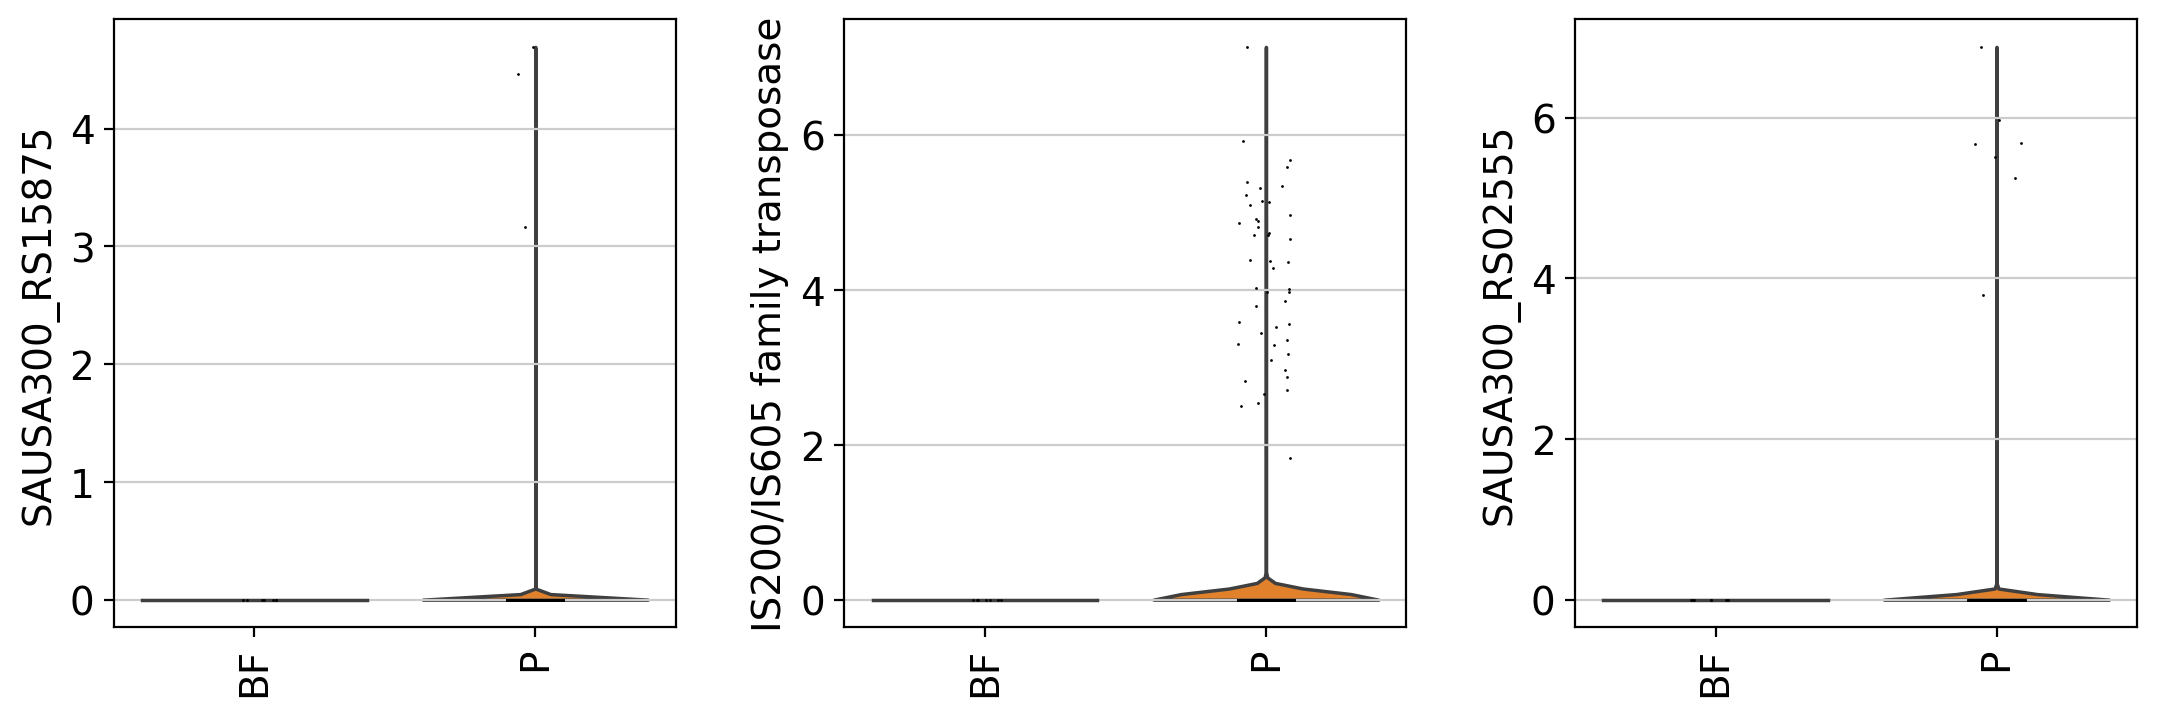

In [35]:
# Visualiseer expressie van top 3 marker genen voor BF cellen in test set
sc.pl.violin(
    adata_test_annotated,
    top_bf_genes,
    groupby='majority_voting',
    rotation=90
)

Top 3 genen voor P: ['SAUSA300_RS15870' 'SAUSA300_RS07720' 'SAUSA300_RS08235']


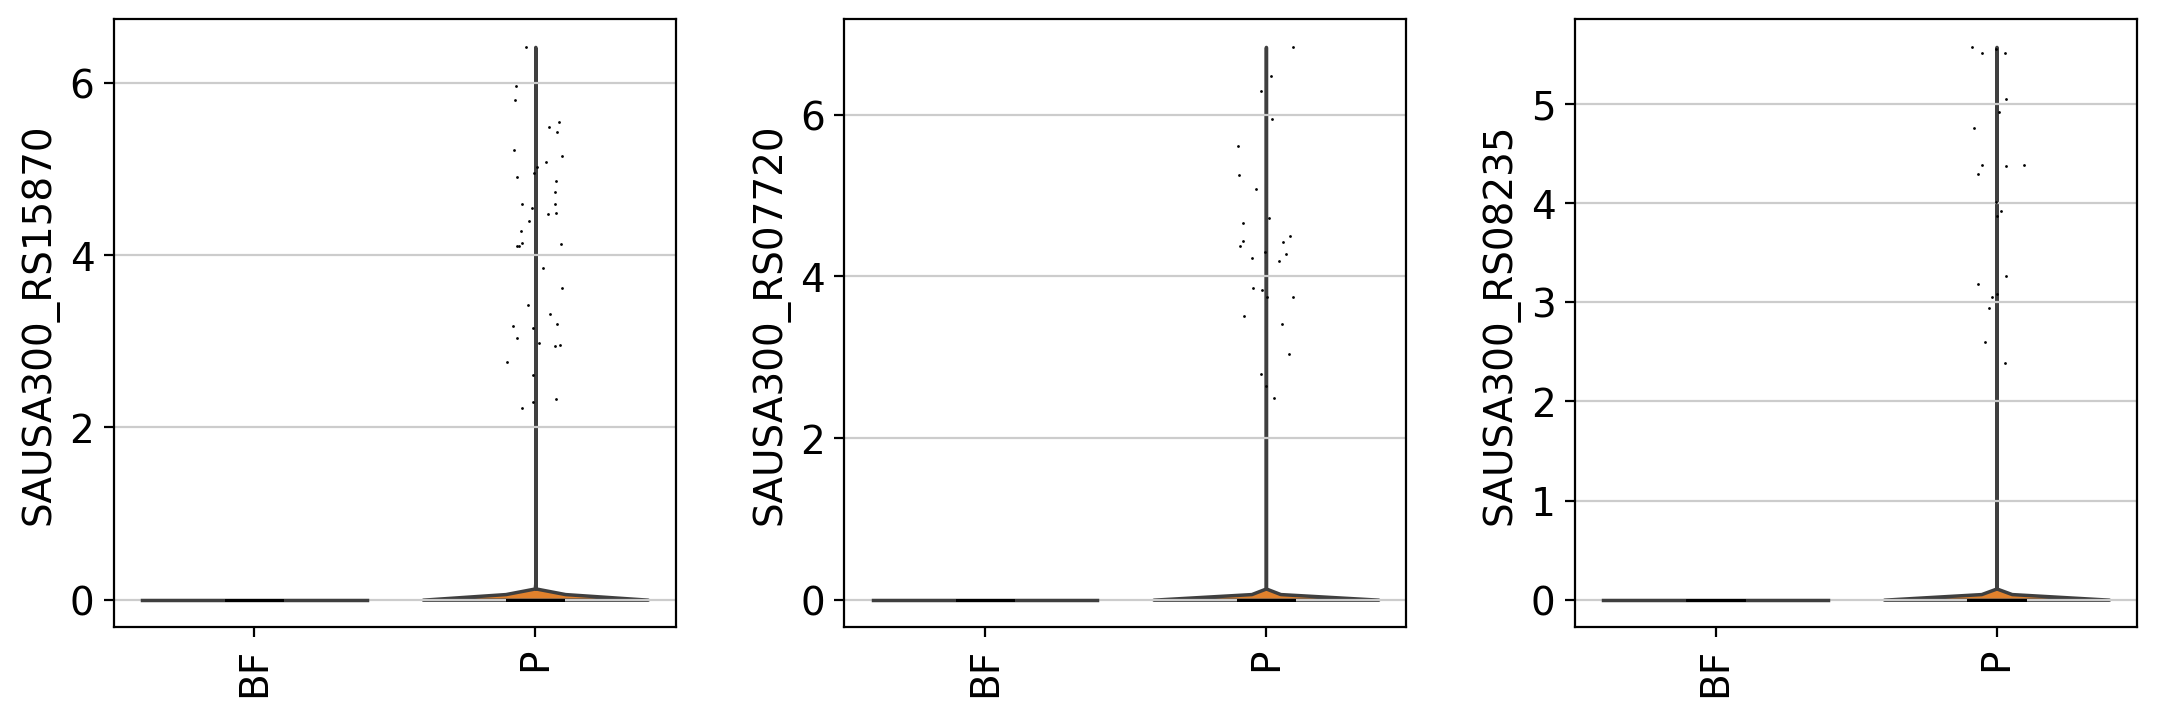

In [36]:
# Visualiseer expressie van top 3 marker genen voor P cellen in de trainingsset
top_p_genes = model.extract_top_markers('P', 3)
print('Top 3 genen voor P:', top_p_genes)

sc.pl.violin(
    adata_train,
    top_p_genes,
    groupby='Type_of_cells',
    rotation=90
)

## 11. Subclustering of Biofilm and Planktonic cells
While the CellTypist model classified cells into two broad categories (Planktonic and Biofilm), the paper by Korshoj & Kielian (2024) demonstrated that both cell types contain transcriptionally distinct subpopulations. To explore this further, we apply the Leiden clustering algorithm to identify subclusters within our dataset, similar to the approach used in the original study where 7 unique subpopulations were identified. This allows us to go beyond a simple binary classification and uncover potential heterogeneity within each cell type.